<a href="https://colab.research.google.com/github/CoolSurfer-Samuel/Retail-Sales-Customer-Intelligence-/blob/main/notebooks/rfm_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd # Load dataset df = pd.read_csv('/content/SuperStoreOrders.csv') # Show first 5 rows print(df.head())

In [ ]:
# Convert date column
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True,
    errors='coerce'
)

# Convert sales to numeric
df['sales'] = pd.to_numeric(
    df['sales'],
    errors='coerce'
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      20067 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           48660 non-null  float64       
 15  qu

In [ ]:
reference_date = df['order_date'].max()

print(reference_date)

2014-12-12 00:00:00


In [ ]:
rfm = df.groupby('customer_name').agg({
    'order_date': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'sales': 'sum'
}).reset_index()

# Rename columns
rfm.columns = [
    'Customer_Name',
    'Recency',
    'Frequency',
    'Monetary'
]

print(rfm.head())

     Customer_Name  Recency  Frequency  Monetary
0    Aaron Bergman       94         89   13814.0
1    Aaron Hawkins        9         56    9171.0
2   Aaron Smayling        4         60    9675.0
3  Adam Bellavance       35         68    7469.0
4        Adam Hart       11         84   14637.0


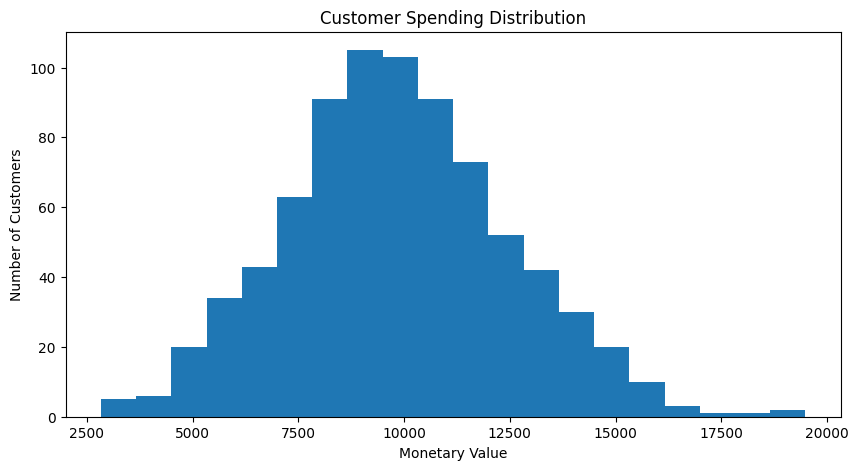

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(rfm['Monetary'], bins=20)

plt.title('Customer Spending Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
# Recency Score
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

# Frequency Score
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

# Monetary Score
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

print(rfm.head())

     Customer_Name  Recency  Frequency  Monetary R_Score F_Score M_Score
0    Aaron Bergman       94         89   13814.0       1       4       4
1    Aaron Hawkins        9         56    9171.0       3       2       2
2   Aaron Smayling        4         60    9675.0       4       2       2
3  Adam Bellavance       35         68    7469.0       2       3       1
4        Adam Hart       11         84   14637.0       3       4       4


In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

print(rfm.head())

     Customer_Name  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0    Aaron Bergman       94         89   13814.0       1       4       4   
1    Aaron Hawkins        9         56    9171.0       3       2       2   
2   Aaron Smayling        4         60    9675.0       4       2       2   
3  Adam Bellavance       35         68    7469.0       2       3       1   
4        Adam Hart       11         84   14637.0       3       4       4   

  RFM_Score  
0       144  
1       322  
2       422  
3       231  
4       344  


In [ ]:
def customer_segment(row):
    if row['RFM_Score'] == '444':
        return 'Champion'
    elif row['R_Score'] == 4:
        return 'Loyal Customer'
    elif row['R_Score'] == 1:
        return 'At Risk'
    else:
        return 'Regular Customer'

rfm['Segment'] = rfm.apply(
    customer_segment,
    axis=1
)

print(rfm[['Customer_Name', 'RFM_Score', 'Segment']].head())

     Customer_Name RFM_Score           Segment
0    Aaron Bergman       144           At Risk
1    Aaron Hawkins       322  Regular Customer
2   Aaron Smayling       422    Loyal Customer
3  Adam Bellavance       231  Regular Customer
4        Adam Hart       344  Regular Customer


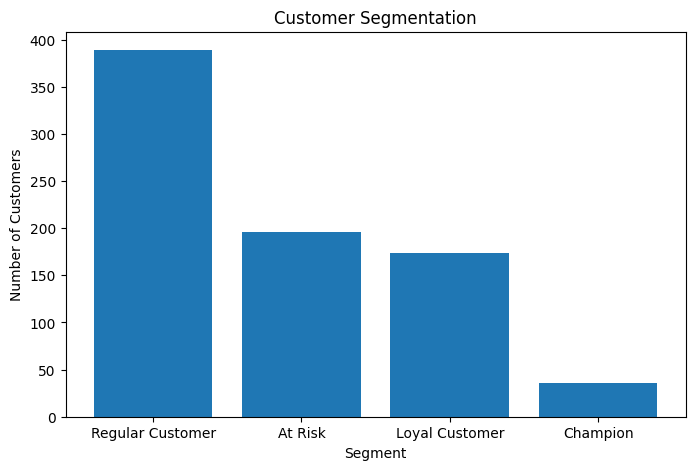

In [ ]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title('Customer Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()